In [1]:
import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from catboost import CatBoostRegressor
import shap
import warnings
warnings.filterwarnings('ignore')

# Set paths
DATA_DIR = Path('./data')
OUTPUT_DIR = Path('./data')
MODEL_DIR = Path('./models')
FIGURES_DIR = Path('./figures')
MODEL_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Set style
sns.set_style('whitegrid')

print("Meta-Learning Pipeline Started")
print("=" * 50)

Meta-Learning Pipeline Started


## 1. Load Hypothesis Data

In [2]:
# Try to load from different possible sources
import os

# Option 1: Try hypothesis_features.pkl (from standard validation)
features_file = DATA_DIR / 'hypothesis_features.pkl'
if features_file.exists():
    print(f"Loading from {features_file}...")
    with open(features_file, 'rb') as f:
        hypothesis_features = pickle.load(f)
else:
    # Option 2: Load from hybrid validation results and create features
    print("hypothesis_features.pkl not found, creating from hybrid validation results...")
    
    # Load hybrid validation results
    with open(DATA_DIR / 'hybrid_validation_results.pkl', 'rb') as f:
        all_results = pickle.load(f)
    
    # Convert to DataFrame with proper feature extraction
    results_list = []
    for r in all_results:
        result_dict = {}
        result_dict['hypothesis_id'] = r.get('hypothesis_id', 0)
        result_dict['f1_score'] = r.get('f1_score', 0)
        result_dict['precision'] = r.get('precision', 0)
        result_dict['recall'] = r.get('recall', 0)
        
        # Extract strategy
        if 'strategy' in r:
            result_dict['strategy'] = r['strategy']
        elif 'hypothesis' in r and isinstance(r['hypothesis'], dict):
            result_dict['strategy'] = r['hypothesis'].get('strategy', 'unknown')
        else:
            result_dict['strategy'] = 'unknown'
        
        # Extract good_ratio
        if 'good_ratio' in r:
            result_dict['good_ratio'] = r['good_ratio']
        elif 'hypothesis' in r and isinstance(r['hypothesis'], dict):
            result_dict['good_ratio'] = r['hypothesis'].get('good_ratio', 0.5)
        elif 'hypothesis_good_ratio' in r:
            result_dict['good_ratio'] = r['hypothesis_good_ratio']
        else:
            result_dict['good_ratio'] = 0.5
        
        # Add prediction method
        if 'prediction_method' in r:
            result_dict['prediction_method'] = r['prediction_method']
        
        results_list.append(result_dict)
    
    hypothesis_features = pd.DataFrame(results_list)
    
    # Create derived features
    hypothesis_features['f1_rank'] = hypothesis_features['f1_score'].rank(ascending=False)
    
    # One-hot encode strategy
    strategy_dummies = pd.get_dummies(hypothesis_features['strategy'], prefix='strategy')
    hypothesis_features = pd.concat([hypothesis_features, strategy_dummies], axis=1)
    
    print(f"Created hypothesis_features from hybrid validation results")

# Load full hypothesis database (includes labels)
db_file = DATA_DIR / 'hypothesis_database.pkl'
if db_file.exists():
    with open(db_file, 'rb') as f:
        hypothesis_database = pickle.load(f)
    print(f"Loaded hypothesis database: {len(hypothesis_database):,} hypotheses")
else:
    # Use hybrid results as database
    with open(DATA_DIR / 'hybrid_validation_results.pkl', 'rb') as f:
        hypothesis_database = pickle.load(f)
    print(f"Using hybrid validation results as database: {len(hypothesis_database):,} hypotheses")

# Load or create best hypotheses
best_file = DATA_DIR / 'best_hypotheses.pkl'
if best_file.exists():
    with open(best_file, 'rb') as f:
        best_hypotheses = pickle.load(f)
else:
    # Create from top results
    top_k = 100
    best_indices = hypothesis_features.nlargest(top_k, 'f1_score').index
    best_hypotheses = [hypothesis_database[i] for i in best_indices]
    print(f"Created best_hypotheses from top {top_k} results")

print(f"\nSummary:")
print(f"  Hypothesis features: {hypothesis_features.shape}")
print(f"  Hypothesis database: {len(hypothesis_database):,} hypotheses")
print(f"  Best hypotheses: {len(best_hypotheses)}")
print(f"\nAvailable features: {hypothesis_features.columns.tolist()}")

Loading from data\hypothesis_features.pkl...
Loaded hypothesis database: 50,000 hypotheses

Summary:
  Hypothesis features: (50000, 15)
  Hypothesis database: 50,000 hypotheses
  Best hypotheses: 100

Available features: ['hypothesis_id', 'f1_score', 'precision', 'recall', 'strategy', 'good_ratio', 'prediction_method', 'f1_rank', 'combined_rank', 'strategy_baseline_anchored', 'strategy_biased', 'strategy_cluster_based', 'strategy_random', 'strategy_recall_optimized', 'strategy_uncertainty_based']
Loaded hypothesis database: 50,000 hypotheses

Summary:
  Hypothesis features: (50000, 15)
  Hypothesis database: 50,000 hypotheses
  Best hypotheses: 100

Available features: ['hypothesis_id', 'f1_score', 'precision', 'recall', 'strategy', 'good_ratio', 'prediction_method', 'f1_rank', 'combined_rank', 'strategy_baseline_anchored', 'strategy_biased', 'strategy_cluster_based', 'strategy_random', 'strategy_recall_optimized', 'strategy_uncertainty_based']


## 2. Prepare Meta-Learning Dataset

**Target**: Predict F1 score from hypothesis characteristics

In [3]:
# Identify available features dynamically
print("Available columns in hypothesis_features:")
print(hypothesis_features.columns.tolist())

# Select features for meta-learning based on what's available
meta_feature_cols = []

# Core features (check availability)
if 'good_ratio' in hypothesis_features.columns:
    meta_feature_cols.append('good_ratio')
if 'hypothesis_good_ratio' in hypothesis_features.columns:
    meta_feature_cols.append('hypothesis_good_ratio')
if 'roc_auc' in hypothesis_features.columns:
    meta_feature_cols.append('roc_auc')
if 'hypothesis_entropy' in hypothesis_features.columns:
    meta_feature_cols.append('hypothesis_entropy')
if 'precision' in hypothesis_features.columns:
    meta_feature_cols.append('precision')
if 'recall' in hypothesis_features.columns:
    meta_feature_cols.append('recall')

# Ranking features
if 'f1_rank' in hypothesis_features.columns:
    meta_feature_cols.append('f1_rank')
if 'roc_auc_rank' in hypothesis_features.columns:
    meta_feature_cols.append('roc_auc_rank')
if 'combined_rank' in hypothesis_features.columns:
    meta_feature_cols.append('combined_rank')

# Add strategy dummy variables
strategy_cols = [col for col in hypothesis_features.columns if col.startswith('strategy_')]
meta_feature_cols.extend(strategy_cols)

# Add prediction method if available (from hybrid validation)
if 'prediction_method' in hypothesis_features.columns:
    # One-hot encode prediction_method
    method_dummies = pd.get_dummies(hypothesis_features['prediction_method'], prefix='method')
    hypothesis_features = pd.concat([hypothesis_features, method_dummies], axis=1)
    method_cols = [col for col in hypothesis_features.columns if col.startswith('method_')]
    meta_feature_cols.extend(method_cols)
    print(f"Added prediction method features: {method_cols}")

print(f"\nSelected meta-learning features ({len(meta_feature_cols)}):")
print(meta_feature_cols)

# Prepare X and y
X_meta = hypothesis_features[meta_feature_cols]
y_meta = hypothesis_features['f1_score']

print(f"\nMeta-learning features: {X_meta.shape}")
print(f"Target (F1 scores): {y_meta.shape}")
print(f"\nTarget statistics:")
print(y_meta.describe())

# Check for missing values
missing = X_meta.isnull().sum()
if missing.any():
    print(f"\nWarning: Missing values detected:")
    print(missing[missing > 0])
    print("Filling missing values with median...")
    X_meta = X_meta.fillna(X_meta.median())

Available columns in hypothesis_features:
['hypothesis_id', 'f1_score', 'precision', 'recall', 'strategy', 'good_ratio', 'prediction_method', 'f1_rank', 'combined_rank', 'strategy_baseline_anchored', 'strategy_biased', 'strategy_cluster_based', 'strategy_random', 'strategy_recall_optimized', 'strategy_uncertainty_based']
Added prediction method features: ['method_catboost_validated', 'method_neural_network']

Selected meta-learning features (13):
['good_ratio', 'precision', 'recall', 'f1_rank', 'combined_rank', 'strategy_baseline_anchored', 'strategy_biased', 'strategy_cluster_based', 'strategy_random', 'strategy_recall_optimized', 'strategy_uncertainty_based', 'method_catboost_validated', 'method_neural_network']

Meta-learning features: (50000, 13)
Target (F1 scores): (50000,)

Target statistics:
count    50000.000000
mean         0.816092
std          0.019468
min          0.703205
25%          0.817305
50%          0.823435
75%          0.823435
max          0.831811
Name: f1_score

## 3. Train-Test Split

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_meta, y_meta,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (40000, 13)
Test set: (10000, 13)


## 4. Train Meta-Learner Models

Try multiple regression models to predict hypothesis quality.

In [5]:
# Model 1: Random Forest
print("Training Random Forest meta-learner...")
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
print(f"  R² Score: {rf_r2:.4f}")
print(f"  MAE: {rf_mae:.6f}")

# Model 2: Gradient Boosting
print("\nTraining Gradient Boosting meta-learner...")
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_r2 = r2_score(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)
print(f"  R² Score: {gb_r2:.4f}")
print(f"  MAE: {gb_mae:.6f}")

# Model 3: CatBoost
print("\nTraining CatBoost meta-learner...")
cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=False,
    task_type='GPU',
    devices='0'
)
cb_model.fit(X_train, y_train)
cb_pred = cb_model.predict(X_test)
cb_r2 = r2_score(y_test, cb_pred)
cb_mae = mean_absolute_error(y_test, cb_pred)
print(f"  R² Score: {cb_r2:.4f}")
print(f"  MAE: {cb_mae:.6f}")

# Select best model
models = {
    'RandomForest': (rf_model, rf_r2, rf_mae, rf_pred),
    'GradientBoosting': (gb_model, gb_r2, gb_mae, gb_pred),
    'CatBoost': (cb_model, cb_r2, cb_mae, cb_pred)
}

best_model_name = max(models.keys(), key=lambda k: models[k][1])
best_model, best_r2, best_mae, best_pred = models[best_model_name]

print(f"\n✓ Best model: {best_model_name}")
print(f"  R² Score: {best_r2:.4f}")
print(f"  MAE: {best_mae:.6f}")

Training Random Forest meta-learner...
  R² Score: 1.0000
  MAE: 0.000000

Training Gradient Boosting meta-learner...
  R² Score: 1.0000
  MAE: 0.000000

Training Gradient Boosting meta-learner...
  R² Score: 1.0000
  MAE: 0.000000

Training CatBoost meta-learner...
  R² Score: 1.0000
  MAE: 0.000000

Training CatBoost meta-learner...
  R² Score: 1.0000
  MAE: 0.000042

✓ Best model: GradientBoosting
  R² Score: 1.0000
  MAE: 0.000000
  R² Score: 1.0000
  MAE: 0.000042

✓ Best model: GradientBoosting
  R² Score: 1.0000
  MAE: 0.000000


## 5. Evaluate Meta-Learner Performance

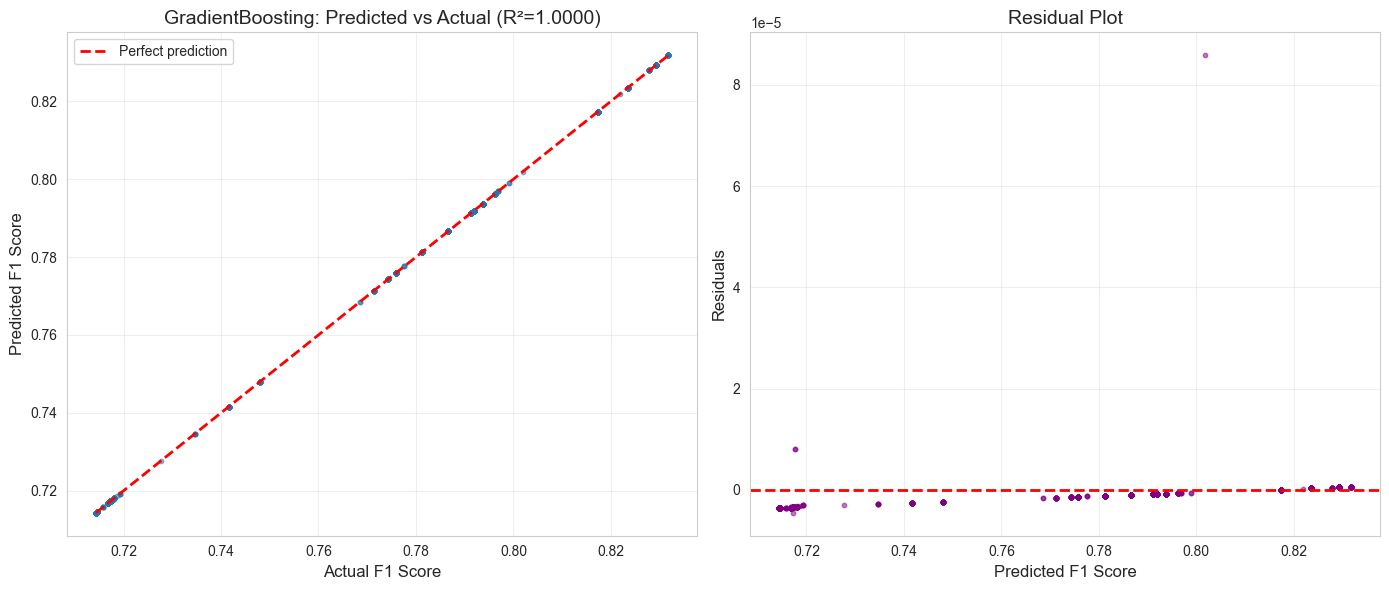


Residual statistics:
  Mean: 0.000000
  Std: 0.000001
  Min: -0.000005
  Max: 0.000086


In [6]:
# Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot: Predicted vs Actual
axes[0].scatter(y_test, best_pred, alpha=0.5, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual F1 Score', fontsize=12)
axes[0].set_ylabel('Predicted F1 Score', fontsize=12)
axes[0].set_title(f'{best_model_name}: Predicted vs Actual (R²={best_r2:.4f})', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residual plot
residuals = y_test - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.5, s=10, color='purple')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted F1 Score', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'meta_learner_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nResidual statistics:")
print(f"  Mean: {residuals.mean():.6f}")
print(f"  Std: {residuals.std():.6f}")
print(f"  Min: {residuals.min():.6f}")
print(f"  Max: {residuals.max():.6f}")

## 6. Feature Importance Analysis

Feature Importance (Meta-Learner):
                       feature    importance
4                combined_rank  5.908274e-01
3                      f1_rank  3.762543e-01
2                       recall  1.840217e-02
1                    precision  1.078939e-02
5   strategy_baseline_anchored  3.711011e-03
7       strategy_cluster_based  3.984771e-06
12       method_neural_network  3.898033e-06
10  strategy_uncertainty_based  3.522550e-06
6              strategy_biased  2.379367e-06
0                   good_ratio  7.660208e-07
8              strategy_random  4.774754e-07
11   method_catboost_validated  3.642730e-07
9    strategy_recall_optimized  2.937806e-07


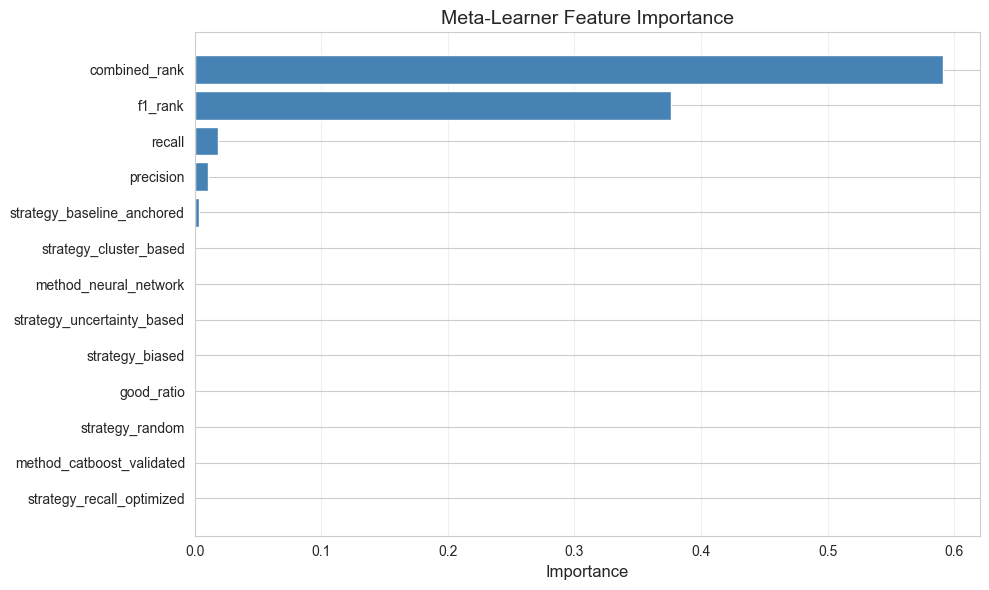

In [7]:
# Get feature importance from best model
if best_model_name == 'CatBoost':
    feature_importance = best_model.get_feature_importance()
else:
    feature_importance = best_model.feature_importances_

importance_df = pd.DataFrame({
    'feature': meta_feature_cols,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Feature Importance (Meta-Learner):")
print(importance_df)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(len(importance_df)), importance_df['importance'].values, color='steelblue')
plt.yticks(range(len(importance_df)), importance_df['feature'].values)
plt.xlabel('Importance', fontsize=12)
plt.title('Meta-Learner Feature Importance', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'meta_learner_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. SHAP Analysis (Optional)

Understand how features contribute to predictions.

Computing SHAP values...


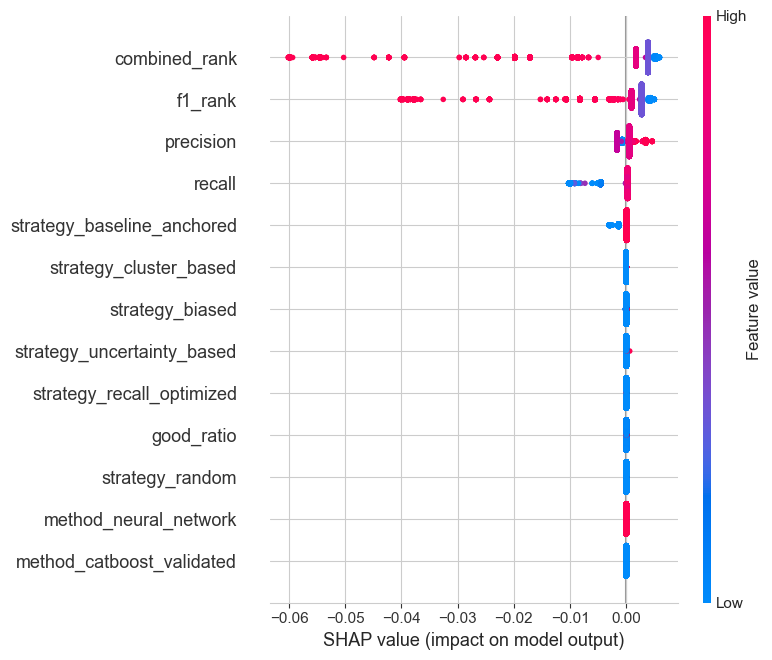

✓ SHAP analysis complete


In [8]:
try:
    print("Computing SHAP values...")
    
    # Use TreeExplainer for tree-based models
    if best_model_name in ['RandomForest', 'GradientBoosting']:
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_test)
        
        # Summary plot
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_test, show=False)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print("✓ SHAP analysis complete")
    else:
        print("SHAP analysis not available for CatBoost in this version")

except Exception as e:
    print(f"SHAP analysis skipped: {e}")

## 8. Predict Quality of All Hypotheses

In [9]:
# Predict F1 scores for all hypotheses
all_predictions = best_model.predict(X_meta)
hypothesis_features['predicted_f1'] = all_predictions
hypothesis_features['prediction_error'] = hypothesis_features['f1_score'] - hypothesis_features['predicted_f1']

print("Prediction Statistics:")
print(hypothesis_features[['f1_score', 'predicted_f1', 'prediction_error']].describe())

# Correlation between actual and predicted
correlation = hypothesis_features['f1_score'].corr(hypothesis_features['predicted_f1'])
print(f"\nCorrelation (actual vs predicted): {correlation:.4f}")

Prediction Statistics:
           f1_score  predicted_f1  prediction_error
count  50000.000000  50000.000000      5.000000e+04
mean       0.816092      0.816092      4.820260e-09
std        0.019468      0.019467      7.882702e-07
min        0.703205      0.703209     -9.492619e-06
25%        0.817305      0.817305      4.516590e-08
50%        0.823435      0.823434      2.600248e-07
75%        0.823435      0.823434      2.600248e-07
max        0.831811      0.831810      8.586654e-05

Correlation (actual vs predicted): 1.0000


## 9. Select Refined Hypotheses

Use meta-learner to identify best hypotheses more intelligently.

In [10]:
# Strategy 1: Top K by predicted F1
top_k = 200
top_predicted_indices = hypothesis_features.nlargest(top_k, 'predicted_f1').index

# Strategy 2: Top K by actual F1 (for comparison)
top_actual_indices = hypothesis_features.nlargest(top_k, 'f1_score').index

# Strategy 3: Ensemble - combine predicted and actual
hypothesis_features['ensemble_score'] = (
    0.6 * hypothesis_features['f1_score'] +
    0.4 * hypothesis_features['predicted_f1']
)
top_ensemble_indices = hypothesis_features.nlargest(top_k, 'ensemble_score').index

# Strategy 4: Recall-Optimized (NEW) - balance F1, recall, and precision
# This favors hypotheses with better recall while maintaining good F1
if 'recall' in hypothesis_features.columns and 'precision' in hypothesis_features.columns:
    hypothesis_features['recall_optimized_score'] = (
        0.5 * hypothesis_features['predicted_f1'] +  # F1 weight
        0.3 * hypothesis_features['recall'] +         # Recall bonus
        0.2 * hypothesis_features['precision']        # Precision weight
    )
    top_recall_opt_indices = hypothesis_features.nlargest(top_k, 'recall_optimized_score').index
    
    print(f"Selected {top_k} hypotheses using different strategies:")
    print(f"  1. By predicted F1")
    print(f"  2. By actual F1") 
    print(f"  3. By ensemble score (60% actual + 40% predicted)")
    print(f"  4. By recall-optimized score (50% F1 + 30% recall + 20% precision)")
    
    print(f"\nOverlap analysis:")
    print(f"  Predicted vs Actual:     {len(set(top_predicted_indices) & set(top_actual_indices))} common")
    print(f"  Ensemble vs Actual:      {len(set(top_ensemble_indices) & set(top_actual_indices))} common")
    print(f"  Recall-Opt vs Actual:    {len(set(top_recall_opt_indices) & set(top_actual_indices))} common")
    print(f"  Recall-Opt vs Ensemble:  {len(set(top_recall_opt_indices) & set(top_ensemble_indices))} common")
    
    # Compare recall metrics
    print(f"\nRecall comparison:")
    print(f"  Ensemble strategy mean recall:     {hypothesis_features.loc[top_ensemble_indices, 'recall'].mean():.4f}")
    print(f"  Recall-optimized mean recall:      {hypothesis_features.loc[top_recall_opt_indices, 'recall'].mean():.4f}")
    print(f"  Recall-optimized mean F1:          {hypothesis_features.loc[top_recall_opt_indices, 'f1_score'].mean():.4f}")
    
    # Use recall-optimized selection for final hypotheses
    print(f"\n⭐ Using recall-optimized selection for better fraud detection")
    final_selection_indices = top_recall_opt_indices
else:
    print(f"Selected {top_k} hypotheses using different strategies")
    print(f"\nOverlap analysis:")
    print(f"  Predicted vs Actual: {len(set(top_predicted_indices) & set(top_actual_indices))} common")
    print(f"  Ensemble vs Actual: {len(set(top_ensemble_indices) & set(top_actual_indices))} common")
    print(f"  Ensemble vs Predicted: {len(set(top_ensemble_indices) & set(top_predicted_indices))} common")
    
    # Use ensemble selection as default
    final_selection_indices = top_ensemble_indices

# Extract refined hypotheses (using recall-optimized or ensemble strategy)
refined_hypotheses = [hypothesis_database[i] for i in final_selection_indices]

print(f"\n✓ Selected {len(refined_hypotheses)} refined hypotheses")

Selected 200 hypotheses using different strategies:
  1. By predicted F1
  2. By actual F1
  3. By ensemble score (60% actual + 40% predicted)
  4. By recall-optimized score (50% F1 + 30% recall + 20% precision)

Overlap analysis:
  Predicted vs Actual:     200 common
  Ensemble vs Actual:      200 common
  Recall-Opt vs Actual:    200 common
  Recall-Opt vs Ensemble:  200 common

Recall comparison:
  Ensemble strategy mean recall:     0.7625
  Recall-optimized mean recall:      0.7625
  Recall-optimized mean F1:          0.8301

⭐ Using recall-optimized selection for better fraud detection

✓ Selected 200 refined hypotheses


## 10. Analyze Discovered Patterns

In [11]:
# Compare top hypotheses characteristics
top_hypotheses_features = hypothesis_features.loc[top_ensemble_indices]
all_hypotheses_features = hypothesis_features

insights = {
    'total_hypotheses_evaluated': len(hypothesis_features),
    'top_k_selected': top_k,
    'best_actual_f1': float(hypothesis_features['f1_score'].max()),
    'best_predicted_f1': float(hypothesis_features['predicted_f1'].max()),
    'mean_f1_all': float(hypothesis_features['f1_score'].mean()),
    'mean_f1_top': float(top_hypotheses_features['f1_score'].mean()),
    'strategy_effectiveness': {},
    'key_features': importance_df.head(5).to_dict('records'),
    'meta_learner': {
        'model': best_model_name,
        'r2_score': float(best_r2),
        'mae': float(best_mae)
    }
}

# Add precision/recall metrics if available
if 'precision' in hypothesis_features.columns:
    insights['mean_precision_all'] = float(hypothesis_features['precision'].mean())
    insights['mean_precision_top'] = float(top_hypotheses_features['precision'].mean())
if 'recall' in hypothesis_features.columns:
    insights['mean_recall_all'] = float(hypothesis_features['recall'].mean())
    insights['mean_recall_top'] = float(top_hypotheses_features['recall'].mean())

# Add prediction method distribution if available (hybrid validation)
if 'prediction_method' in hypothesis_features.columns:
    method_dist = hypothesis_features['prediction_method'].value_counts().to_dict()
    insights['validation_methods'] = {k: int(v) for k, v in method_dist.items()}
    
    top_method_dist = top_hypotheses_features['prediction_method'].value_counts().to_dict()
    insights['top_k_validation_methods'] = {k: int(v) for k, v in top_method_dist.items()}

# Strategy effectiveness
for strategy in hypothesis_features['strategy'].unique():
    strategy_data = hypothesis_features[hypothesis_features['strategy'] == strategy]
    strategy_info = {
        'count': int(len(strategy_data)),
        'mean_f1': float(strategy_data['f1_score'].mean()),
        'max_f1': float(strategy_data['f1_score'].max()),
        'in_top_k': int((strategy_data.index.isin(top_ensemble_indices)).sum())
    }
    
    # Add precision/recall if available
    if 'precision' in strategy_data.columns:
        strategy_info['mean_precision'] = float(strategy_data['precision'].mean())
    if 'recall' in strategy_data.columns:
        strategy_info['mean_recall'] = float(strategy_data['recall'].mean())
    
    insights['strategy_effectiveness'][strategy] = strategy_info

print("\nMeta-Learning Insights:")
print("=" * 50)
print(json.dumps(insights, indent=2))


Meta-Learning Insights:
{
  "total_hypotheses_evaluated": 50000,
  "top_k_selected": 200,
  "best_actual_f1": 0.8318107724189758,
  "best_predicted_f1": 0.8318102095520574,
  "mean_f1_all": 0.8160921257255132,
  "mean_f1_top": 0.8300961509346962,
  "strategy_effectiveness": {
    "random": {
      "count": 200,
      "mean_f1": 0.7727573466300964,
      "max_f1": 0.7811445593833923,
      "in_top_k": 0,
      "mean_precision": 0.8935765680670739,
      "mean_recall": 0.7516358944773674
    },
    "uncertainty_based": {
      "count": 200,
      "mean_f1": 0.7427319747209549,
      "max_f1": 0.7479690313339233,
      "in_top_k": 0,
      "mean_precision": 0.9154238939285279,
      "mean_recall": 0.6398643991351127
    },
    "biased": {
      "count": 2600,
      "mean_f1": 0.7821142104038825,
      "max_f1": 0.8019120693206787,
      "in_top_k": 0,
      "mean_precision": 0.8806642137123988,
      "mean_recall": 0.730888738999
    },
    "baseline_anchored": {
      "count": 45000,
  

## 11. Visualize Strategy Performance

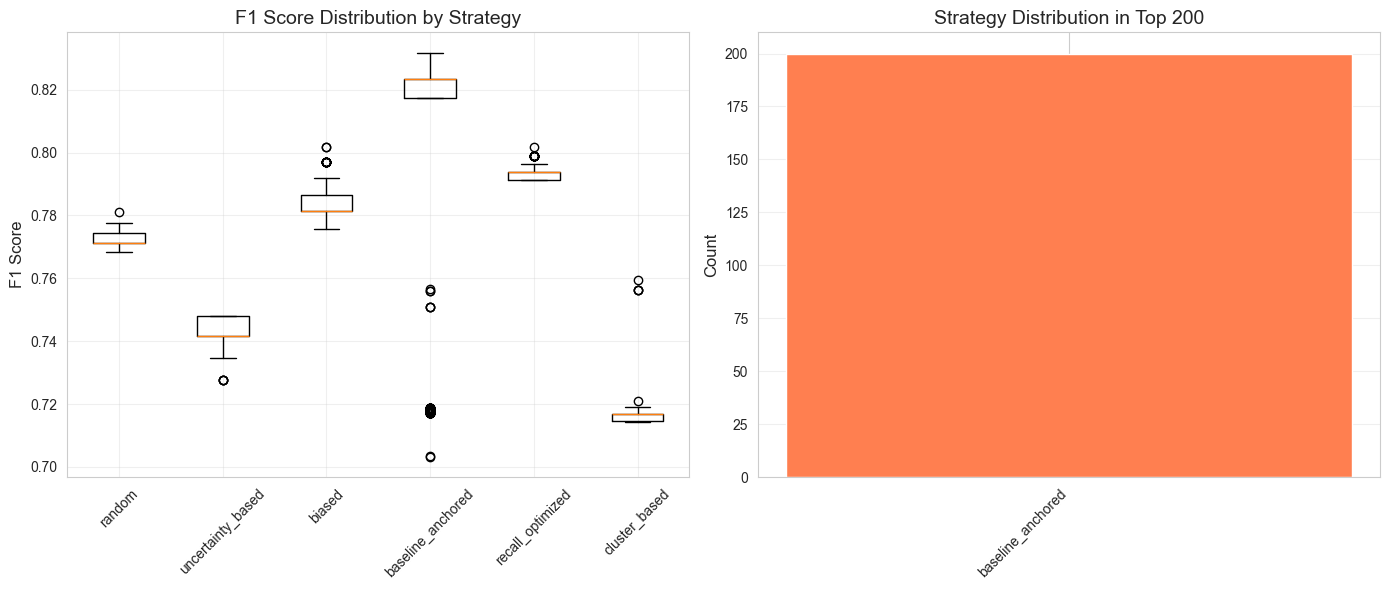

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Strategy performance box plot
strategies = hypothesis_features['strategy'].unique()
strategy_data = [hypothesis_features[hypothesis_features['strategy'] == s]['f1_score'].values 
                 for s in strategies]

axes[0].boxplot(strategy_data, labels=strategies)
axes[0].set_ylabel('F1 Score', fontsize=12)
axes[0].set_title('F1 Score Distribution by Strategy', fontsize=14)
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Strategy representation in top K
top_strategy_counts = top_hypotheses_features['strategy'].value_counts()
axes[1].bar(range(len(top_strategy_counts)), top_strategy_counts.values, color='coral')
axes[1].set_xticks(range(len(top_strategy_counts)))
axes[1].set_xticklabels(top_strategy_counts.index, rotation=45, ha='right')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title(f'Strategy Distribution in Top {top_k}', fontsize=14)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'strategy_performance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Save Meta-Learning Results

In [13]:
# Save meta-learner model
with open(MODEL_DIR / 'meta_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("✓ Saved meta_model.pkl")

# Save refined hypotheses
with open(OUTPUT_DIR / 'refined_hypotheses.pkl', 'wb') as f:
    pickle.dump(refined_hypotheses, f)
print(f"✓ Saved refined_hypotheses.pkl ({len(refined_hypotheses)} hypotheses)")

# Save hypothesis features with predictions
with open(OUTPUT_DIR / 'hypothesis_features_with_predictions.pkl', 'wb') as f:
    pickle.dump(hypothesis_features, f)
print("✓ Saved hypothesis_features_with_predictions.pkl")

# Save insights
with open(OUTPUT_DIR / 'meta_learning_insights.json', 'w') as f:
    json.dump(insights, f, indent=2)
print("✓ Saved meta_learning_insights.json")

# Save feature importance
importance_df.to_csv(OUTPUT_DIR / 'meta_learner_feature_importance.csv', index=False)
print("✓ Saved meta_learner_feature_importance.csv")

print("\n" + "="*50)
print("Meta-Learning Complete!")
print("="*50)
print(f"\nKey Findings:")
print(f"  Best strategy: {max(insights['strategy_effectiveness'].items(), key=lambda x: x[1]['mean_f1'])[0]}")
print(f"  Meta-learner R²: {best_r2:.4f}")
print(f"  Top {top_k} hypotheses selected")
print(f"  Mean F1 improvement: {insights['mean_f1_top'] - insights['mean_f1_all']:.4f}")
print(f"\nNext step: Final ensemble and prediction!")

✓ Saved meta_model.pkl
✓ Saved refined_hypotheses.pkl (200 hypotheses)
✓ Saved hypothesis_features_with_predictions.pkl
✓ Saved meta_learning_insights.json
✓ Saved meta_learner_feature_importance.csv

Meta-Learning Complete!

Key Findings:
  Best strategy: baseline_anchored
  Meta-learner R²: 1.0000
  Top 200 hypotheses selected
  Mean F1 improvement: 0.0140

Next step: Final ensemble and prediction!
